[run_id] 20260304_022550_61a8ff0f
[run_dir] C:\Users\Owner\Documents\Repos\Fracture\VCM_3_4\output\NetworkSimulations\20260304_022550_61a8ff0f


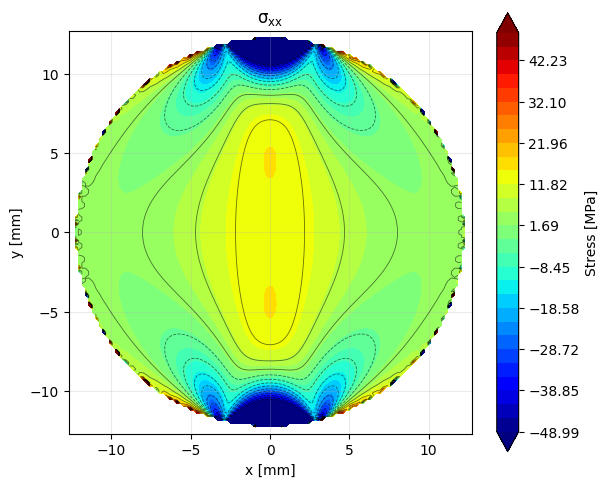

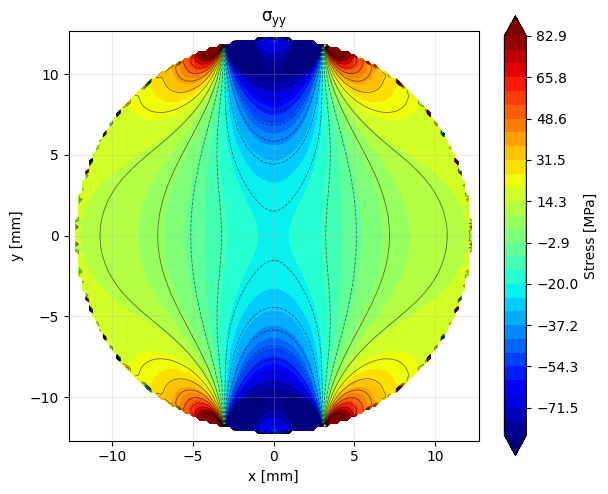

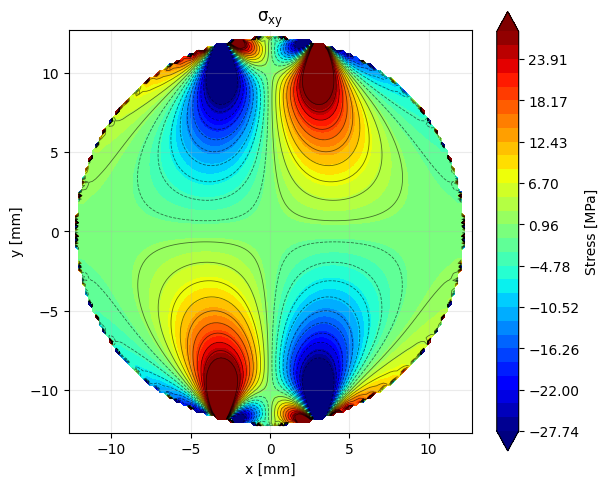

[bem] reference C_rel_m_per_N = 3.0311829271367737e-06

[outer-cycle] 1/8 mode=iterative
[solve] start: cycle_00_initial (Nv=8, Ne=4)
[solve] done : cycle_00_initial


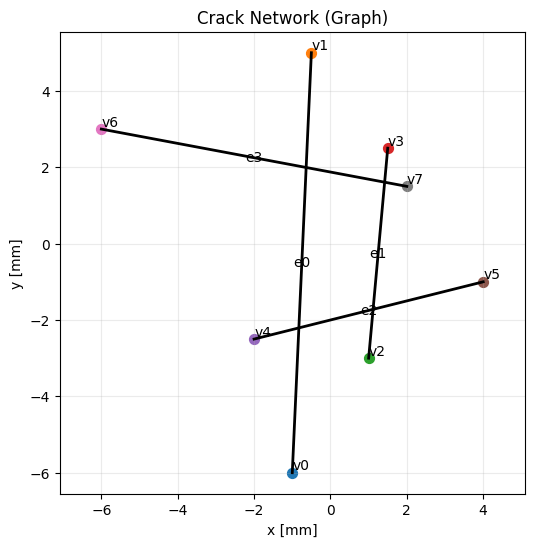

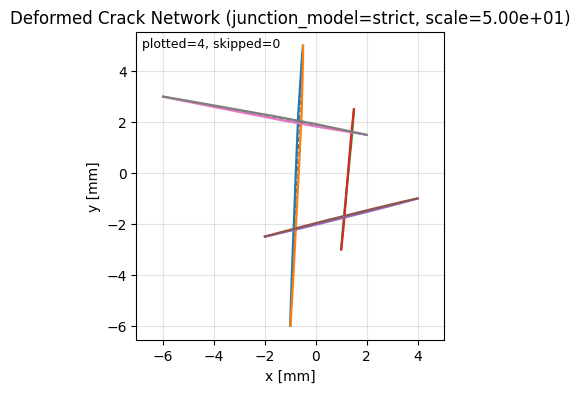

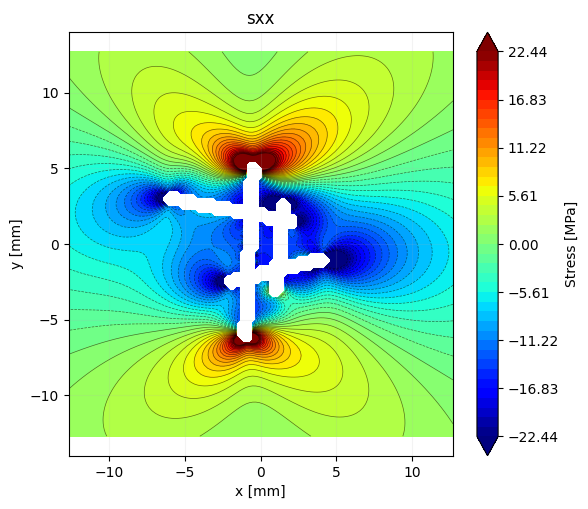

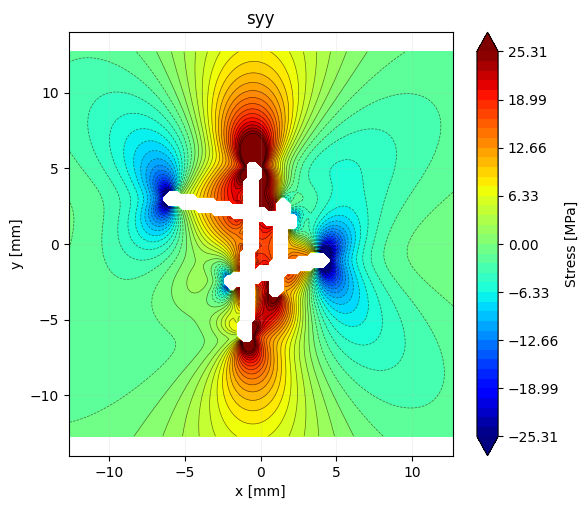

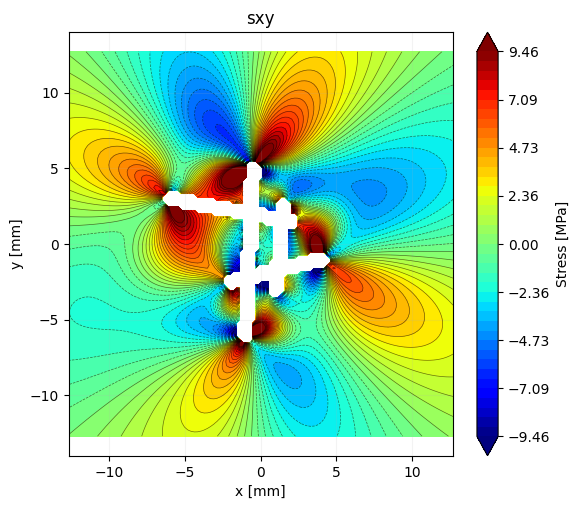

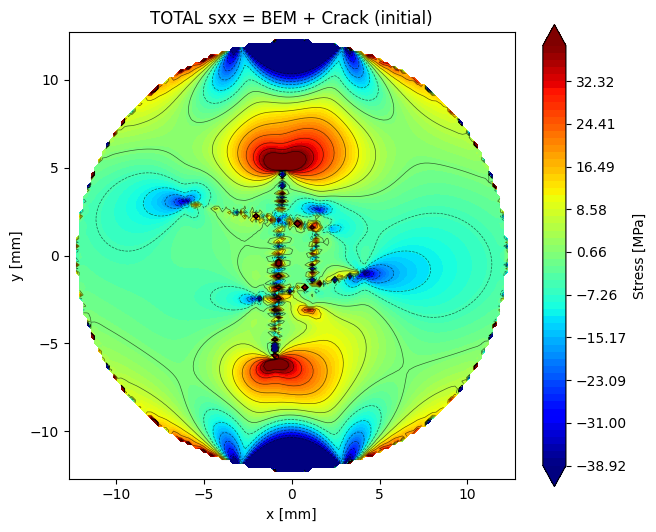

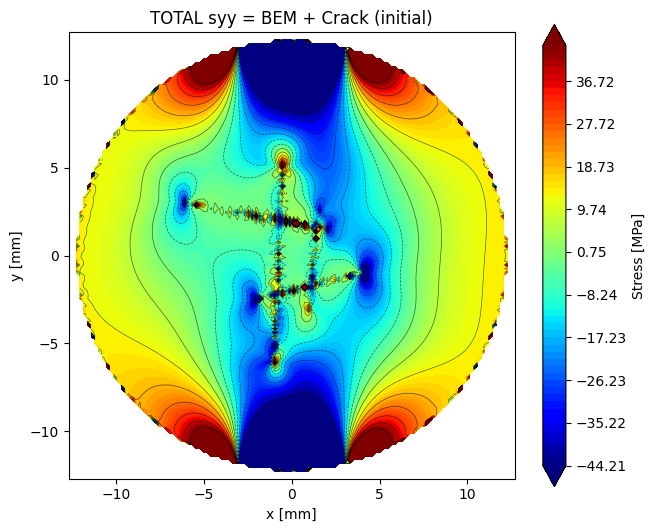

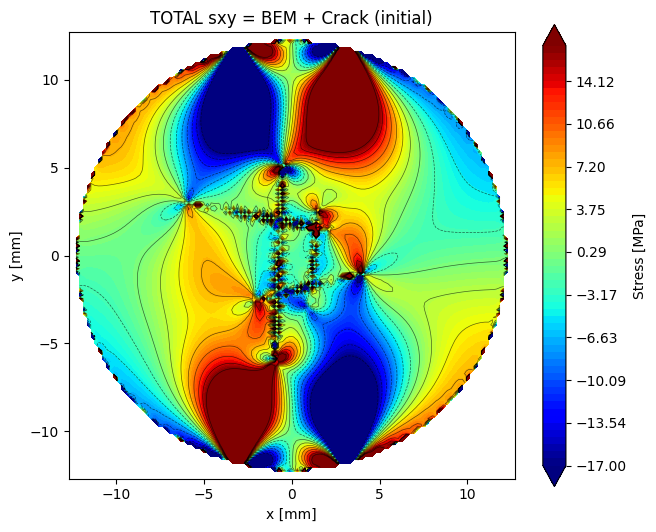

✓ Loaded network: 20 vertices, 20 edges
[inner-metrics] total=1 outer=1 inner=1 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=nan Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=1.749108e+00 Keff_max=3.105533e+00 ntip=8
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=2 outer=1 inner=2 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=3 outer=1 inner=3 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=4 outer=1 inner=4 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inne

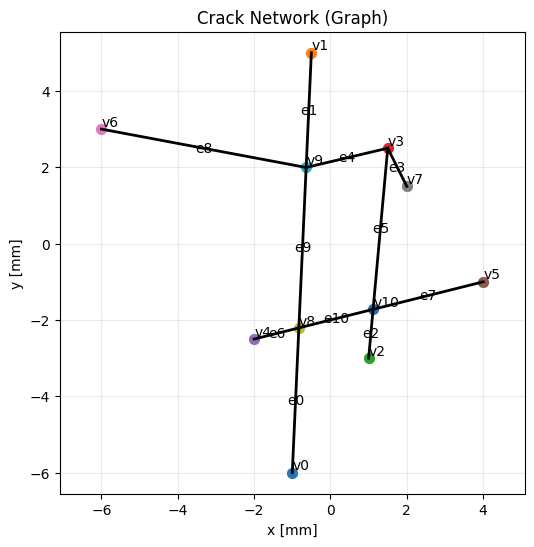

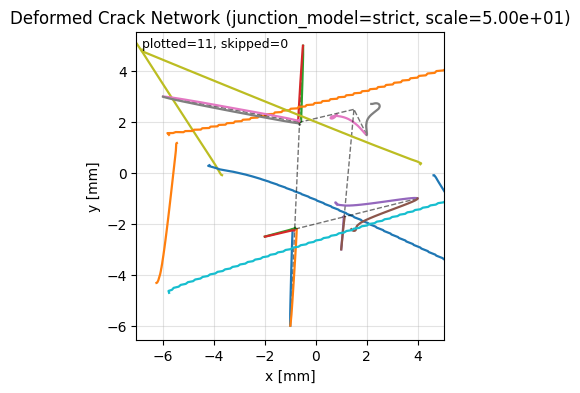

✓ Loaded network: 11 vertices, 11 edges
[solve] start: cycle_01_post_simplify (Nv=11, Ne=11)
[solve] done : cycle_01_post_simplify


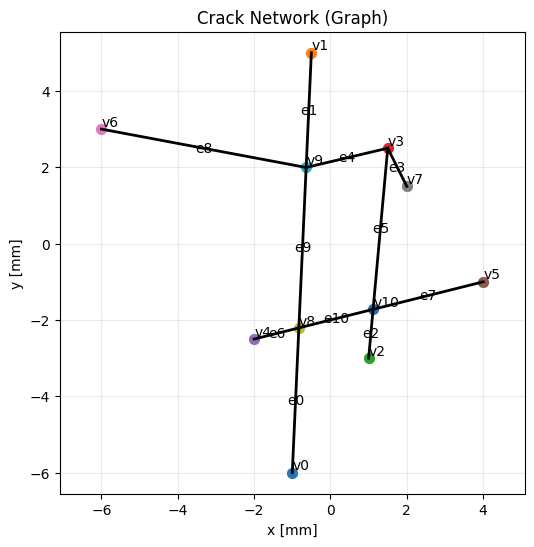

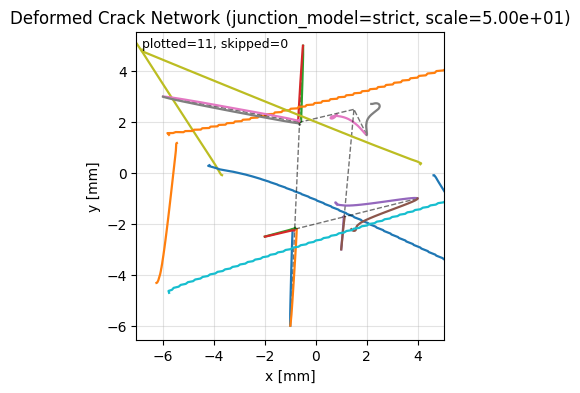

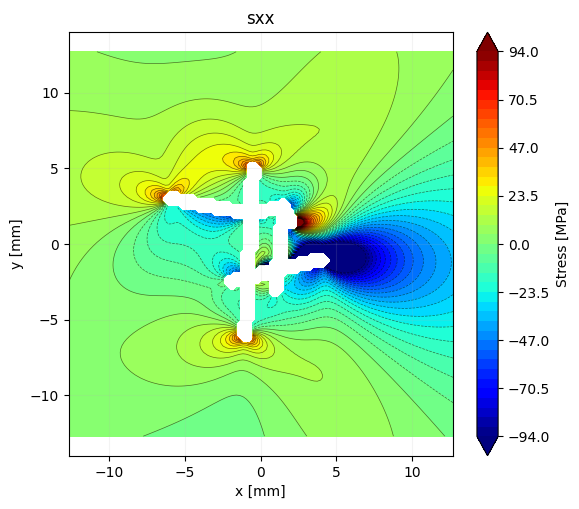

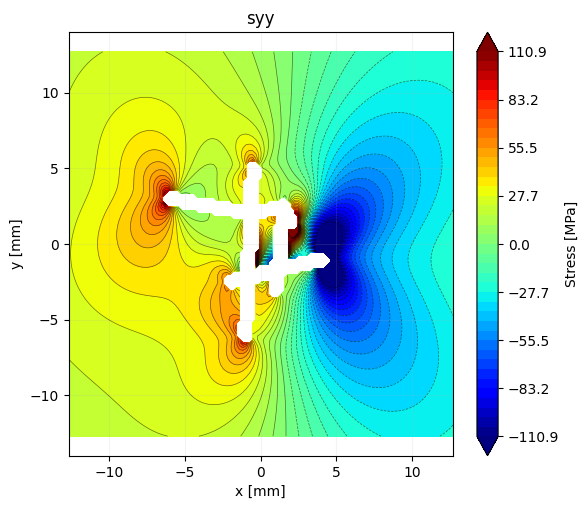

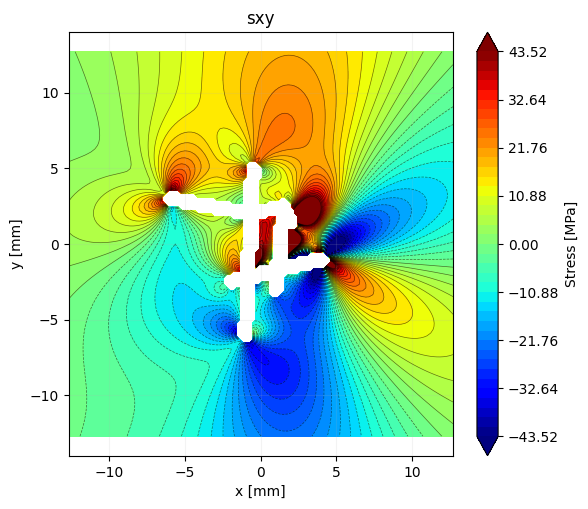

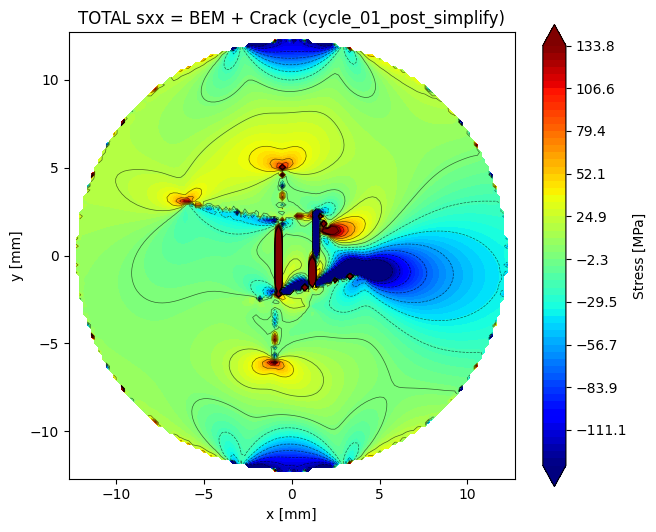

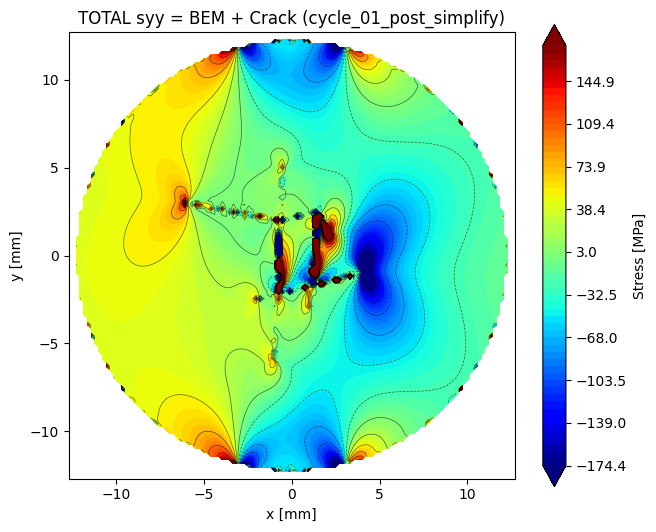

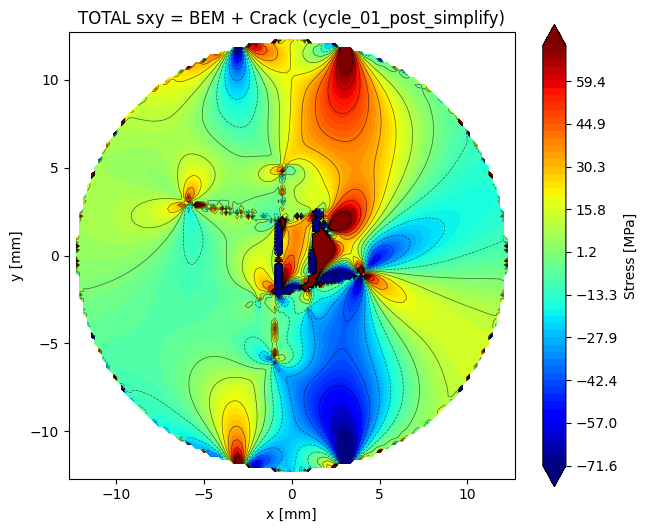

✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=9 outer=2 inner=1 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=10 outer=2 inner=2 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=11 outer=2 inner=3 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18 edges
[inner-metrics] total=12 outer=2 inner=4 L=3.148921e-02 alpha=6.214475e+01 dalpha_rel=0.000000e+00 Pinf=0.000000e+00 Q=1.449044e-01 Crel=3.031183e-06 Keff_mean=2.728258e+00 Keff_max=6.226842e+00 ntip=7
✓ Loaded network: 18 vertices, 18

KeyboardInterrupt: 

In [15]:
from pathlib import Path
import os, sys
import json
import shutil
import subprocess
from datetime import datetime
from dataclasses import fields, MISSING
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Repo import path
# -----------------------
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fracture_utils.Ubem.brazilian_disk_bem import BrazilianDiskParams
from fracture_utils.Ubem.boundary_conditions import build_boundary
from fracture_utils.Ubem.bem_solver import BEMSolver2D
from fracture_utils.Ubem.bem_stress_field import circle_inside
from fracture_utils.Ubem.bem_stress_plotter import (
    ContourOpts,
    eval_and_plot_stress_components_contours_separate,
)
from fracture_utils.Ubem.direct_kkt_coupling import build_bem_dense_operators
from fracture_utils.Ubem.crack_energetics import compute_disk_boundary_compliance_from_solver
from fracture_utils.Ubem.disk_iterative_coupling import (
    compute_crack_boundary_tractions_direct,
    solve_bem_with_extra_boundary_tractions,
)
from fracture_utils.Ubem.disk_crack_plotting import PlotParams, make_standard_plot_hook

import importlib
import fracture_utils.Ubem.disk_network_propagation as dnp
importlib.reload(dnp)
CrackGrowthParams = dnp.CrackGrowthParams
run_network_growth_uncoupled = dnp.run_network_growth_uncoupled


# -----------------------
# User config
# -----------------------
mm = 1e-3

# Displacement-controlled loading (borrowed from BEM_displacement.ipynb)
U_Y_TOP_IMPOSED = -1e-5
U_Y_BOTTOM_IMPOSED = 0.0

# Disk + material params (same family as previous notebooks)
disk = BrazilianDiskParams(
    R=25.4e-3 / 2,
    P_total=3.8e3,     # kept for compatibility (not used in imposed_uy solve)
    E=231.52e9,
    nu=0.3,
    n_elem=90,
    
    gauss_n=6,
    plane_strain=True,
    arc_half_angle_deg=15.0,
    h=6.35e-3,
    n_grid=120,
    pad_frac=0.03,
)

# Crack network + growth setup (borrowed from disk_compression_inclined.ipynb)
Kc_demo = 0.0e6
vertices = np.array([
    [0, -1.0*mm, -6.0*mm],
    [1, -0.5*mm,  5.0*mm],
    [2,  1.0*mm, -3.0*mm],
    [3,  1.5*mm,  2.5*mm],
    [4, -2.0*mm, -2.5*mm],
    [5,  4.0*mm, -1.0*mm],
    [6, -6.0*mm,  3.0*mm],
    [7,  2.0*mm,  1.5*mm],
], float)
connectivity = np.array([
    [0, 1],
    [2, 3],
    [4, 5],
    [6, 7],
], int)

def _git_short_hash(default: str = "nogit") -> str:
    try:
        out = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=repo_root)
        return out.decode("utf-8", errors="ignore").strip() or default
    except Exception:
        return default


def _run_id() -> str:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{ts}_{_git_short_hash()}"


def _dataclass_defaults(dc_type):
    d = {}
    for f in fields(dc_type):
        if f.default is not MISSING:
            d[f.name] = f.default
        elif f.default_factory is not MISSING:  # type: ignore[attr-defined]
            d[f.name] = f.default_factory()      # type: ignore[misc]
        else:
            d[f.name] = None
    return d


def _fmt(v):
    if isinstance(v, np.ndarray):
        return np.array2string(v, separator=", ")
    if isinstance(v, (list, tuple, dict)):
        try:
            return json.dumps(v, ensure_ascii=False)
        except Exception:
            return str(v)
    return str(v)


def _write_provenance(run_dir: Path, run_id: str, table_rows):
    prov = run_dir / f"provenance_{run_id}.md"
    lines = []
    lines.append(f"# Provenance - {run_id}\n")
    lines.append("\n")
    lines.append(f"- Generated: {datetime.now().isoformat()}\n")
    lines.append(f"- Repo root: `{repo_root}`\n")
    lines.append(f"- Notebook: `VCM_3_4/notebooks/disk_energetics.ipynb`\n")
    lines.append("\n")
    lines.append("## Run Configuration\n")
    lines.append("\n")
    lines.append("| Group | Parameter | Default | Effective | Source |\n")
    lines.append("|---|---|---|---|---|\n")
    for g, p, d, e, s in table_rows:
        lines.append(f"| {g} | `{p}` | `{_fmt(d)}` | `{_fmt(e)}` | {s} |\n")
    prov.write_text("".join(lines), encoding="utf-8")


def _write_provenance_json(run_dir: Path, run_id: str, table_rows):
    prov_json = run_dir / f"provenance_{run_id}.json"
    rows = []
    for g, p, d, e, s in table_rows:
        rows.append({
            "group": g,
            "parameter": p,
            "default": d,
            "effective": e,
            "source": s,
        })
    payload = {
        "run_id": run_id,
        "generated_at": datetime.now().isoformat(),
        "repo_root": str(repo_root),
        "notebook": "VCM_3_4/notebooks/disk_energetics.ipynb",
        "rows": rows,
    }

    def _json_default(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.floating, np.integer)):
            return obj.item()
        return str(obj)

    prov_json.write_text(json.dumps(payload, ensure_ascii=False, indent=2, default=_json_default), encoding="utf-8")


run_id = _run_id()
run_dir = repo_root / "output" / "NetworkSimulations" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
print(f"[run_id] {run_id}")
print(f"[run_dir] {run_dir}")

OUT_DIR = run_dir
BEM_DIR = run_dir
RUN_DIR = run_dir
BEM_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------
# Displacement-controlled BEM solve
# -----------------------
def _build_disk_mesh(params: BrazilianDiskParams):
    return build_boundary({"type": "circle", "R": float(params.R), "n_boundary": int(params.n_elem), "center": (0.0, 0.0)})


def _arc_masks(mesh, params: BrazilianDiskParams):
    theta_deg = np.asarray(mesh.theta_deg, dtype=float)
    arc_half = float(params.arc_half_angle_deg)
    top = (theta_deg >= 90.0 - arc_half) & (theta_deg <= 90.0 + arc_half)
    bot = (theta_deg >= -90.0 - arc_half) & (theta_deg <= -90.0 + arc_half)
    return top, bot


def solve_disk_imposed_uy(params: BrazilianDiskParams, uy_top: float, uy_bottom: float = 0.0):
    mesh = _build_disk_mesh(params)
    top, bot = _arc_masks(mesh, params)
    n = int(mesh.n_seg)

    solver = BEMSolver2D(E=float(params.E), nu=float(params.nu), h=float(params.h), plane_strain=bool(params.plane_strain))
    for i in range(n):
        solver.add_element(
            float(mesh.x1[i]), float(mesh.y1[i]),
            float(mesh.x2[i]), float(mesh.y2[i]),
            True, 0.0, 0.0,
        )

    CplusH, G = build_bem_dense_operators(
        segments=solver.segs,
        E=float(params.E),
        nu=float(params.nu),
        plane_strain=bool(params.plane_strain),
        gauss_n=int(params.gauss_n),
    )

    C_bem = np.hstack([CplusH, -G])
    C_bc = np.zeros((2 * n, 4 * n), float)
    d = np.zeros((2 * n,), float)

    for i in range(n):
        r0 = 2 * i
        r1 = 2 * i + 1

        # keep u_x free by enforcing t_x = 0
        C_bc[r0, 2 * n + 2 * i + 0] = 1.0

        if top[i]:
            C_bc[r1, 2 * i + 1] = 1.0
            d[r1] = float(uy_top)
        elif bot[i]:
            C_bc[r1, 2 * i + 1] = 1.0
            d[r1] = float(uy_bottom)
        else:
            C_bc[r1, 2 * n + 2 * i + 1] = 1.0

    A = np.vstack([C_bem, C_bc])
    b = np.concatenate([np.zeros((2 * n,), float), d])
    y, *_ = np.linalg.lstsq(A, b, rcond=None)

    u = y[:2 * n]
    t = y[2 * n:]
    solver.u_x = np.asarray(u[0::2], float).copy()
    solver.u_y = np.asarray(u[1::2], float).copy()
    solver.t_x = np.asarray(t[0::2], float).copy()
    solver.t_y = np.asarray(t[1::2], float).copy()
    solver._colloc_xy = np.column_stack([np.asarray(mesh.xm, float), np.asarray(mesh.ym, float)])

    return solver, mesh


def save_bem_field_arrays_and_plots(solver, params: BrazilianDiskParams, out_dir: Path, basename: str = "brazilian_disk"):
    bbox = (-params.R, params.R, -params.R, params.R)
    inside = circle_inside(float(params.R), center=(0.0, 0.0), pad=float(params.pad_frac) * float(params.R))

    opts_common = dict(
        dpi=300,
        show=True,
        robust=True,
        robust_pct=97.0,
        n_levels=30,
        n_line_levels=20,
        x_scale=1e3,
        y_scale=1e3,
        x_label="x [mm]",
        y_label="y [mm]",
        value_scale=1e-6,
        cbar_label="Stress [MPa]",
        cmap="jet",
    )

    xs, ys, Sxx, Syy, Sxy, _ = eval_and_plot_stress_components_contours_separate(
        solver,
        bbox=bbox,
        out_dir=out_dir,
        basename=basename,
        n=int(params.n_grid),
        inside=inside,
        normalize_by=None,
        opts_xx=ContourOpts(**opts_common, title=r"$\sigma_{xx}$", symmetric=True),
        opts_yy=ContourOpts(**opts_common, title=r"$\sigma_{yy}$", symmetric=True),
        opts_xy=ContourOpts(**opts_common, title=r"$\sigma_{xy}$", symmetric=True),
    )

    # Save with canonical names expected by run_network_growth_uncoupled
    np.save(out_dir / "xs.npy", xs)
    np.save(out_dir / "ys.npy", ys)
    np.save(out_dir / "Sxx.npy", Sxx)
    np.save(out_dir / "Syy.npy", Syy)
    np.save(out_dir / "Sxy.npy", Sxy)

    return xs, ys, Sxx, Syy, Sxy


solver_bem, mesh_bem = solve_disk_imposed_uy(
    disk,
    uy_top=float(U_Y_TOP_IMPOSED),
    uy_bottom=float(U_Y_BOTTOM_IMPOSED),
)
_ = save_bem_field_arrays_and_plots(solver_bem, disk, BEM_DIR)

comp_ref = compute_disk_boundary_compliance_from_solver(
    solver=solver_bem,
    mesh=mesh_bem,
    h=float(disk.h),
    arc_half_angle_deg=float(disk.arc_half_angle_deg),
)
C_REL_REF = float(comp_ref.get("C_rel_m_per_N", np.nan))
print("[bem] reference C_rel_m_per_N =", C_REL_REF)

# Mutable compliance state updated after each outer-cycle BEM update.
_compliance_state = {"C_rel": float(C_REL_REF)}


def compliance_callback(**kwargs):
    return float(_compliance_state["C_rel"])


# -----------------------
# Crack growth run + metrics save
# -----------------------
plot_params = PlotParams(
    cmap="jet",
    match_limits_to_crack=True,
    robust=True,
    robust_pct=97.0,
    symmetric=True,
    vmax_factor=2.0,
    n_levels=60,
    n_line_levels=15,
    dpi=300,
)

hook = make_standard_plot_hook(
    bem_dir=BEM_DIR,
    combined_out_dir=RUN_DIR,
    plot_params=plot_params,
    show_initial=True,
    show_cycles=True,
    show_final=True,
)

# Mode switch
#   "no_coupling" : single growth run using fixed BEM field
#   "iterative"   : outer-loop traction feedback update of BEM
COUPLING_METHOD = "iterative"
OUTER_CYCLES = 8
n_inner_max_for_index = 8


def _network_to_arrays(net):
    V = np.array([[int(v.id), float(v.x), float(v.y)] for v in net.vertices], float)
    C = np.array([[int(e.v0), int(e.v1)] for e in net.edges], int) if len(net.edges) else np.zeros((0, 2), int)
    return V, C


def _cycle_dir_sort_key(p: Path):
    name = p.name
    idx = -1
    if name.startswith("cycle_"):
        parts = name.split("_")
        if len(parts) > 1 and parts[1].isdigit():
            idx = int(parts[1])

    phase_rank = 0
    if "terminated" in name:
        phase_rank = 4
    elif "post_simplify" in name:
        phase_rank = 3
    elif "pre_simplify" in name:
        phase_rank = 2
    elif "initial" in name:
        phase_rank = 1
    return (idx, phase_rank, name)


def _latest_cycle_plot_dir(outer_dir: Path) -> Path:
    candidates = []
    for p in outer_dir.glob("cycle_*"):
        if p.is_dir() and (p / "network_graph.png").exists() and (p / "deformed_network.png").exists():
            candidates.append(p)
    if not candidates:
        return outer_dir
    return sorted(candidates, key=_cycle_dir_sort_key)[-1]


def _save_outer_boundary_snapshot_to_cycle_dir(*, source_bem_dir: Path, outer_dir: Path, outer_cycle: int):
    dst = _latest_cycle_plot_dir(outer_dir)
    file_map = [
        ("xs.npy", "outer_boundary_xs.npy"),
        ("ys.npy", "outer_boundary_ys.npy"),
        ("Sxx.npy", "outer_boundary_Sxx.npy"),
        ("Syy.npy", "outer_boundary_Syy.npy"),
        ("Sxy.npy", "outer_boundary_Sxy.npy"),
        ("brazilian_disk_iter_sxx_contour.png", "outer_boundary_sxx_contour.png"),
        ("brazilian_disk_iter_syy_contour.png", "outer_boundary_syy_contour.png"),
        ("brazilian_disk_iter_sxy_contour.png", "outer_boundary_sxy_contour.png"),
    ]

    copied = []
    for src_name, dst_name in file_map:
        src = Path(source_bem_dir) / src_name
        if src.exists():
            shutil.copy2(src, dst / dst_name)
            copied.append(dst_name)

    manifest = {
        "outer_cycle": int(outer_cycle),
        "saved_at": datetime.now().isoformat(),
        "source_bem_dir": str(source_bem_dir),
        "destination_dir": str(dst),
        "copied_files": copied,
    }
    (dst / f"outer_boundary_snapshot_outer_{int(outer_cycle):02d}.json").write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"[outer-cycle] saved outer-boundary snapshot to {dst}")


base_growth_kwargs = dict(
    max_cycles=4,
    L_limit_mm=20.0,
    vertex_high=25,
    max_inner_cycles_per_outer=6,
    enable_inner_cycle_metrics_save=True,
    domain_area_m2=float(np.pi * disk.R * disk.R),
    disk_radius_m=float(disk.R),
    arc_half_angle_deg=float(disk.arc_half_angle_deg),
    boundary_band_frac=0.05,
    loading_axis=(0.0, 1.0),
    control_mode="displacement",
    disp_delta_m=float(abs(U_Y_TOP_IMPOSED - U_Y_BOTTOM_IMPOSED)),
    disk_thickness_m=float(disk.h),
    inner_cycle_max_for_index=int(n_inner_max_for_index),
    compliance_evaluator=compliance_callback,
    check_tip_outside_disk=True,
    tip_outside_tolerance_m=0.0,
    # Match VCM_3_0 kinked-propagation strategy: iterative intersections + conservative simplification.
    intersection_detect_mode="iterative",
    intersection_verbose=False,
    simplify_each_step=False,
    simplification_config={
        "max_angle_deviation": 5.0,
        "min_edge_length": 0.50 * mm,
        "merge_at_degree2": True,
        "remove_degree2_nodes": False,
        "merge_vertex_tolerance": 1.0 * mm,
        "max_merged_edge_length": 20.0 * mm,
        "preserve_tips": True,
        "preserve_junctions": True,
    },
    solver_kwargs={
        "ne_half": 40,
        "Kc_demo": Kc_demo,
        "refine_kinks": False,
        "refine_junction_endpoints": False,
        "endpoint_min_nodes": 4,
        "kink_side_nodes": 1,
        "tip_cluster": "power",
        "tip_cluster_power": 2.5,
        "other_min_panels": 4,
    },
)

V_curr = vertices.copy()
C_curr = connectivity.copy()
all_rows = []
res_final = None

if COUPLING_METHOD == "no_coupling":
    grow = CrackGrowthParams(**base_growth_kwargs)
    res_final = run_network_growth_uncoupled(
        bem_dir=BEM_DIR,
        out_dir=RUN_DIR,
        vertices=V_curr,
        connectivity=C_curr,
        params=grow,
        plot_hook=hook,
    )

    m = np.load(RUN_DIR / "inner_cycle_metrics.npz", allow_pickle=True)
    nloc = int(np.asarray(m["total_cycle_number"]).size)
    for i in range(nloc):
        row = {k: np.asarray(m[k])[i] for k in m.files}
        all_rows.append(row)

elif COUPLING_METHOD == "iterative":
    boundary_mesh = build_boundary({"type": "circle", "R": float(disk.R), "n_boundary": int(disk.n_elem), "center": (0.0, 0.0)})

    for oc in range(1, int(OUTER_CYCLES) + 1):
        print(f"\n[outer-cycle] {oc}/{OUTER_CYCLES} mode=iterative")
        outer_dir = RUN_DIR / f"outer_{oc:02d}"
        outer_dir.mkdir(parents=True, exist_ok=True)

        grow = CrackGrowthParams(**base_growth_kwargs)
        res_outer = run_network_growth_uncoupled(
            bem_dir=BEM_DIR,
            out_dir=outer_dir,
            vertices=V_curr,
            connectivity=C_curr,
            params=grow,
            plot_hook=hook,
        )
        res_final = res_outer

        # Concatenate metrics with continuous total_cycle_number over outer loops
        m = np.load(outer_dir / "inner_cycle_metrics.npz", allow_pickle=True)
        nloc = int(np.asarray(m["total_cycle_number"]).size)
        cycle_offset = (oc - 1) * int(n_inner_max_for_index)
        for i in range(nloc):
            row = {k: np.asarray(m[k])[i] for k in m.files}
            row["total_cycle_number"] = int(row["total_cycle_number"]) + int(cycle_offset)
            row["outer_loop_index"] = int(oc)
            all_rows.append(row)

        # Iterative coupling update: crack-induced boundary tractions -> BEM
        tx_cr, ty_cr = compute_crack_boundary_tractions_direct(res=res_outer, boundary_mesh=boundary_mesh)
        solver_iter, mesh_iter, _ = solve_bem_with_extra_boundary_tractions(
            disk_params=disk,
            bem_dir=BEM_DIR,
            tx_extra=-tx_cr,
            ty_extra=-ty_cr,
            show=False,
        )
        _save_outer_boundary_snapshot_to_cycle_dir(
            source_bem_dir=BEM_DIR,
            outer_dir=outer_dir,
            outer_cycle=oc,
        )

        comp_iter = compute_disk_boundary_compliance_from_solver(
            solver=solver_iter,
            mesh=mesh_iter,
            h=float(disk.h),
            arc_half_angle_deg=float(disk.arc_half_angle_deg),
        )
        _compliance_state["C_rel"] = float(comp_iter.get("C_rel_m_per_N", np.nan))
        print(f"[outer-cycle] updated C_rel_m_per_N = {_compliance_state['C_rel']:.6e}")

        # Next outer cycle starts from updated network
        V_curr, C_curr = _network_to_arrays(res_outer.calc.network)

else:
    raise ValueError("COUPLING_METHOD must be 'no_coupling' or 'iterative'.")


# Save combined metrics to canonical location for plotting
if not all_rows:
    raise RuntimeError("No inner-cycle metrics collected.")

all_keys = sorted({k for r in all_rows for k in r.keys()})
combined = {}
for k in all_keys:
    vals = [r.get(k, np.nan) for r in all_rows]
    arr = np.asarray(vals)
    if arr.dtype.kind in ("i", "u", "f", "b"):
        combined[k] = arr
    else:
        combined[k] = arr.astype(str)

np.savez(RUN_DIR / "inner_cycle_metrics.npz", **combined)


# -----------------------
# Load + plot saved inner-cycle metrics vs total cycle number
# -----------------------
metrics_npz = RUN_DIR / "inner_cycle_metrics.npz"
if not metrics_npz.exists():
    raise FileNotFoundError(f"Missing metrics file: {metrics_npz}")

m = np.load(metrics_npz, allow_pickle=True)
x = np.asarray(m["total_cycle_number"], int)

# Print all per-inner-cycle metrics (including K_eff) in table form
exclude_nonmetrics = {"control_mode"}
print("\n[inner-cycle metrics]\n")
metric_cols = [k for k in m.files if k not in exclude_nonmetrics and np.asarray(m[k]).ndim == 1 and np.asarray(m[k]).size == x.size]
metric_cols = sorted(metric_cols)

# Keep identifiers first for readability
front = [k for k in ["total_cycle_number", "outer_loop_index", "outer_cycle", "inner_step", "global_step"] if k in metric_cols]
rest = [k for k in metric_cols if k not in front]
cols = front + rest

print(" | ".join(cols))
print("-|-".join(["---"] * len(cols)))
for i in range(x.size):
    vals = []
    for k in cols:
        v = np.asarray(m[k])[i]
        arr_k = np.asarray(m[k])
        if np.issubdtype(arr_k.dtype, np.integer):
            vals.append(f"{int(v)}")
        elif np.issubdtype(arr_k.dtype, np.floating):
            vals.append("nan" if not np.isfinite(v) else f"{float(v):.6e}")
        else:
            vals.append(str(v))
    print(" | ".join(vals))

# Plot ALL numeric metrics versus total cycle number
exclude = {
    "total_cycle_number",
    "cycle_index",
    "outer_cycle",
    "inner_step",
    "global_step",
    "control_mode",
}
metric_keys = []
for k in m.files:
    if k in exclude:
        continue
    arr = np.asarray(m[k])
    if arr.ndim == 1 and arr.size == x.size and np.issubdtype(arr.dtype, np.number):
        metric_keys.append(k)

metric_keys = sorted(metric_keys)
if not metric_keys:
    raise RuntimeError("No numeric metric arrays found to plot.")

n = len(metric_keys)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.6*nrows), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()

for i, k in enumerate(metric_keys):
    ax = axs[i]
    y = np.asarray(m[k], float)
    ax.plot(x, y, "-o", ms=3)
    ax.set_xlabel("total_cycle_number")
    ax.set_ylabel(k)
    ax.set_title(k)
    ax.grid(True, alpha=0.3)

for j in range(len(metric_keys), len(axs)):
    axs[j].set_axis_off()

plt.show()
print("[done] disk energetics workflow complete")




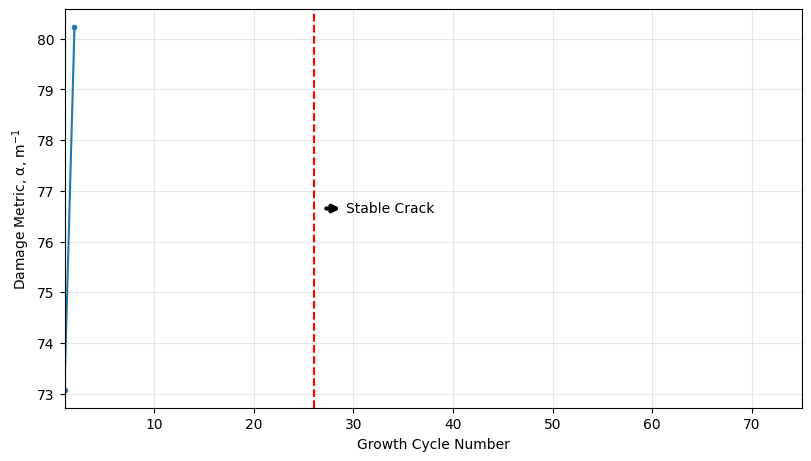

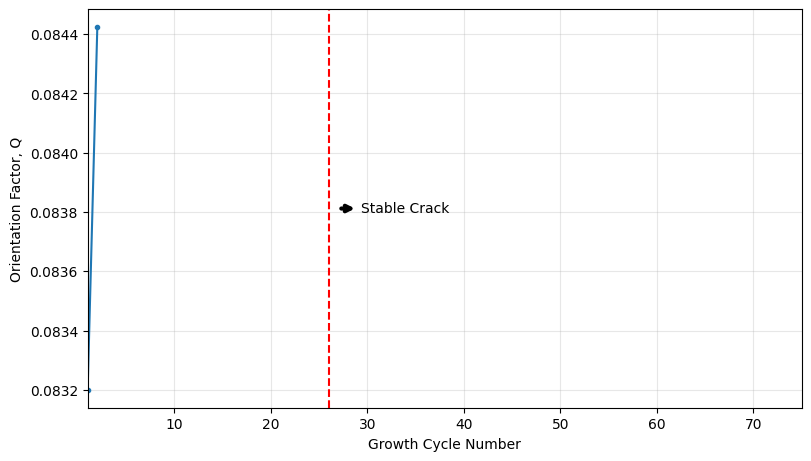

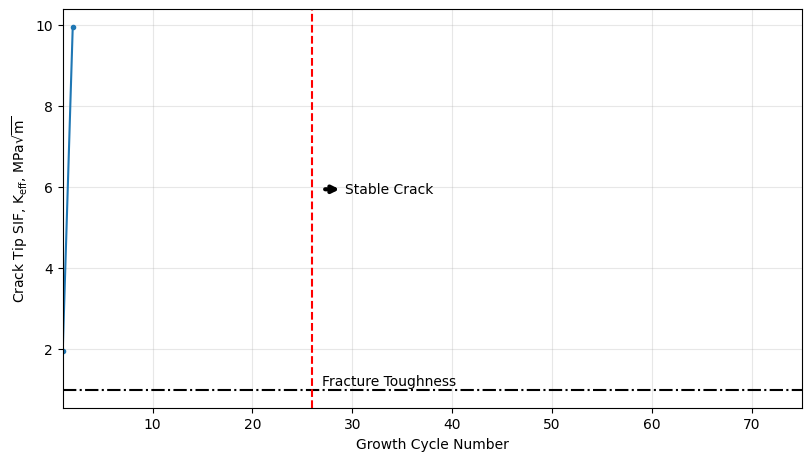

[metrics source] outer_* metrics
[cycles plotted] min=1, max=2, count=2
[selected keys] alpha=alpha, Q=Q, Keffe_mean=K_eff_mean_MPa_sqrt_m
[saved plots] C:\Users\Owner\Documents\Repos\Fracture\VCM_3_4\output\NetworkSimulations\20260303_220859_61a8ff0f\plots


In [13]:
# Extract alpha, Q, Keffe_mean vs total cycle number and plot/save them
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# Resolve run directory and metrics path with fallback if RUN_DIR is not defined
if "RUN_DIR" in globals():
    run_dir = Path(RUN_DIR)
else:
    cwd = Path.cwd().resolve()
    repo_root_guess = cwd.parent if cwd.name == "notebooks" else cwd
    base = repo_root_guess / "output" / "NetworkSimulations"
    candidates = sorted([p for p in base.glob("*") if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No run directories found in {base}")
    run_dir = candidates[-1]

metrics_npz = run_dir / "inner_cycle_metrics.npz"


def _rows_to_metrics(rows):
    keys = sorted({k for r in rows for k in r.keys()})
    out = {}
    for k in keys:
        vals = [r.get(k, np.nan) for r in rows]
        arr = np.asarray(vals)
        if arr.dtype.kind in ("i", "u", "f", "b"):
            out[k] = arr
        else:
            out[k] = arr.astype(str)
    return out


def _build_from_outer_dirs(base_dir):
    rows = []
    running_total = 0
    outer_dirs = sorted([p for p in base_dir.glob("outer_*") if p.is_dir()])

    for od in outer_dirs:
        p = od / "inner_cycle_metrics.npz"
        if not p.exists():
            continue

        mloc = np.load(p, allow_pickle=True)
        if "total_cycle_number" not in mloc.files:
            continue

        nloc = int(np.asarray(mloc["total_cycle_number"]).size)
        if nloc == 0:
            continue

        local_total = np.asarray(mloc["total_cycle_number"], int)
        local_total = local_total - int(np.min(local_total)) + 1

        mo = re.search(r"outer_(\d+)", od.name)
        oc = int(mo.group(1)) if mo else np.nan

        for i in range(nloc):
            row = {k: np.asarray(mloc[k])[i] for k in mloc.files}
            row["total_cycle_number"] = int(local_total[i]) + int(running_total)
            if "outer_loop_index" not in row:
                row["outer_loop_index"] = int(oc) if np.isfinite(oc) else np.nan
            rows.append(row)

        running_total = int(max(r["total_cycle_number"] for r in rows))

    return _rows_to_metrics(rows) if rows else None


m = None
source_label = None

# Prefer reconstruction from per-outer files because it is robust to interrupted runs.
m_outer = _build_from_outer_dirs(run_dir)
if m_outer is not None and "total_cycle_number" in m_outer:
    m = m_outer
    source_label = "outer_* metrics"
elif metrics_npz.exists():
    mz = np.load(metrics_npz, allow_pickle=True)
    m = {k: np.asarray(mz[k]) for k in mz.files}
    source_label = str(metrics_npz)
else:
    raise FileNotFoundError(
        f"No metrics found in {run_dir}. Run the growth workflow cell first."
    )

x_all = np.asarray(m["total_cycle_number"], int)
mask = (x_all >= 1) & (x_all <= 75)
if not np.any(mask):
    raise RuntimeError("No cycles in [1, 75] found for plotting.")

x = x_all[mask]


def _pick_metric(candidates, label):
    for k in candidates:
        if k in m:
            return np.asarray(m[k], float), k
    raise KeyError(f"Could not find {label}. Tried {candidates}. Available keys: {list(m.keys())}")


def _pick_keffe_mean():
    explicit = [
        "Keffe_mean",
        "K_effe_mean",
        "K_eff_mean",
        "Keff_mean",
        "K_eff_mean_MPa_sqrt_m",
    ]
    for k in explicit:
        if k in m:
            return np.asarray(m[k], float), k

    for k in m.keys():
        kl = str(k).lower()
        if ("k_eff" in kl or "keff" in kl) and "mean" in kl:
            arr = np.asarray(m[k])
            if arr.ndim == 1 and arr.size == x_all.size and np.issubdtype(arr.dtype, np.number):
                return np.asarray(arr, float), k

    raise KeyError(
        "Could not find Keffe_mean-like metric. "
        f"Available keys: {list(m.keys())}"
    )


def _add_stable_crack_annotation(ax, y):
    x_line = 26
    ax.axvline(x_line, color="red", linestyle="--", linewidth=1.5)

    y = np.asarray(y, float)
    y_finite = y[np.isfinite(y)]
    if y_finite.size == 0:
        y_mid = 0.0
    else:
        y_mid = 0.5 * (float(np.min(y_finite)) + float(np.max(y_finite)))

    x0 = x_line + 1.0
    x1 = x_line + 3.0
    ax.annotate(
        "",
        xy=(x1, y_mid),
        xytext=(x0, y_mid),
        arrowprops=dict(arrowstyle="->", color="black", linewidth=3.0),
    )
    ax.text(x1 + 0.3, y_mid, "Stable Crack", color="black", va="center", ha="left")


alpha_all, alpha_key = _pick_metric(["alpha", "alpha_mean"], "alpha")
Q_all, Q_key = _pick_metric(["Q", "Q_mean", "Q_total"], "Q")
Keffe_all, Keffe_key = _pick_keffe_mean()

alpha = alpha_all[mask]
Q = Q_all[mask]
Keffe = Keffe_all[mask]

# Save directory for plots
plots_dir = run_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

# 1) Damage Metric alpha
fig1, ax1 = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax1.plot(x, alpha, "-o", ms=3)
ax1.set_xlabel("Growth Cycle Number")
ax1.set_ylabel(r"Damage Metric, $\alpha$, m$^{-1}$")
ax1.set_xlim(1, 75)
ax1.grid(True, alpha=0.3)
_add_stable_crack_annotation(ax1, alpha)
fig1.savefig(plots_dir / "damage_metric_alpha_vs_growth_cycle.png", dpi=300)

# 2) Orientation Factor Q
fig2, ax2 = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax2.plot(x, Q, "-o", ms=3)
ax2.set_xlabel("Growth Cycle Number")
ax2.set_ylabel("Orientation Factor, Q")
ax2.set_xlim(1, 75)
ax2.grid(True, alpha=0.3)
_add_stable_crack_annotation(ax2, Q)
fig2.savefig(plots_dir / "orientation_factor_Q_vs_growth_cycle.png", dpi=300)

# 3) Crack Tip SIF Keff
fig3, ax3 = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax3.plot(x, Keffe, "-o", ms=3)
ax3.set_xlabel("Growth Cycle Number")
ax3.set_ylabel(r"Crack Tip SIF, K$_{eff}$, MPa$\sqrt{m}$")
ax3.set_xlim(1, 75)
ax3.axhline(1.00, color="black", linestyle="-.", linewidth=1.5)
ax3.text(27.0, 1.03, "Fracture Toughness", color="black", va="bottom", ha="left")
ax3.grid(True, alpha=0.3)
_add_stable_crack_annotation(ax3, Keffe)
fig3.savefig(plots_dir / "crack_tip_sif_keff_vs_growth_cycle.png", dpi=300)

plt.show()
print(f"[metrics source] {source_label}")
print(f"[cycles plotted] min={int(np.min(x))}, max={int(np.max(x))}, count={int(x.size)}")
print(f"[selected keys] alpha={alpha_key}, Q={Q_key}, Keffe_mean={Keffe_key}")
print(f"[saved plots] {plots_dir}")
